In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import statsmodels.api as sm
from dominance_analysis import Dominance

from utilities import save_mpl_fig

COVARIATES_CSV = "../data/country_fes_covariates.csv"

COVS = ["log_gdppc", "egdi", "english", "gci", "vdem"]
OUTCOMES = {"breach": "fe_breach", "serious": "fe_breach_serious"}

df = (
    pd
    .read_csv(COVARIATES_CSV)
    .dropna()
    .reset_index(drop=True)
)
df.head(3)

,cc3,country,fe_breach_serious,fe_breach,gdppc,egdi,vdem,gci,english,log_gdppc
0,AUS,Australia,0.891,0.941,58224.486034,0.902424,0.866727,97.47,1.0,10.972061
1,GBR,UK,0.798,0.830,42839.088769,0.904098,0.863455,99.54,1.0,10.665206
2,DNK,Denmark,0.457,0.687,59007.919499,0.889374,0.919182,92.60,0.0,10.985427


## Models

In [2]:
results = {}
for name, outcome in OUTCOMES.items():
    results[f"{name} M1"] = sm.OLS(df[outcome], sm.add_constant(df[["log_gdppc"]])).fit()
    results[f"{name} M2"] = sm.OLS(df[outcome], sm.add_constant(df[COVS])).fit()

cols = {}
for model, res in results.items():
    stars = pd.cut(res.pvalues, [0, 0.001, 0.01, 0.05, 0.1, 1], labels=["***", "**", "*", "+", ""])
    col = res.params.map("{:.3f}".format) + stars.astype(str) + res.bse.map(" ({:.3f})".format)
    col["R2"] = f"{res.rsquared:.3f}"
    col["adj R2"] = f"{res.rsquared_adj:.3f}"
    col["N"] = f"{int(res.nobs)}"
    cols[model] = col

df_models = pd.DataFrame(cols).reindex([*COVS, "const", "R2", "adj R2"]).fillna("")
df_models

,breach M1,breach M2,serious M1,serious M2
log_gdppc,0.102*** (0.019),0.001 (0.046),0.055*** (0.014),-0.017 (0.034)
egdi,,0.457 (0.335),,0.517* (0.248)
english,,0.213*** (0.049),,0.166*** (0.036)
gci,,0.001 (0.001),,-0.001 (0.001)
vdem,,0.436* (0.165),,0.245+ (0.122)
const,-0.561** (0.177),-0.337 (0.233),-0.237+ (0.126),-0.054 (0.173)
R2,0.359,0.610,0.244,0.501
adj R2,0.346,0.568,0.229,0.447


## Shapley decomposition

Each covariate's average marginal contribution to $R^2$ over all covariate
orderings ("Total Dominance" in the dominance-analysis package); shares sum
to the full-model $R^2$. Bootstrap CIs from 2,000 country resamples (~3 min).

In [3]:
%%capture

shares = {}
for name, outcome in OUTCOMES.items():
    dom = Dominance(
        data=df[[outcome, *COVS]],
        target=outcome,
        objective=1,  # 1 = linear regression, subsets scored by R2
        top_k=None,  # inc. all covariates
    )
    # get contrib to r2
    dom.incremental_rsquare() 
    shares[name] = dom.dominance_stats()["Total Dominance"].astype(float)

In [4]:
df_shapley = (
    pd.DataFrame(shares)
    .rename_axis(index="cov", columns="outcome")
    .sort_values("serious", ascending=False)
)
df_shapley.round(3)

outcome,breach,serious
cov,,
english,0.131,0.173
egdi,0.126,0.111
vdem,0.148,0.096
log_gdppc,0.120,0.090
gci,0.085,0.031


In [5]:
%%capture
# bootstrap over countries
_n = 2000
rng = np.random.default_rng(0)
reps = []
for name, outcome in OUTCOMES.items():
    for _b in range(_n):
        df_resample = df.sample(len(df), replace=True, random_state=rng)
        dom = Dominance(
            data=df_resample[[outcome, *COVS]],
            target=outcome,
            objective=1,  # 1 = linear regression, subsets scored by R2
            top_k=None,  # inc. all covariates
        )
        dom.incremental_rsquare()
        reps.append(
            dom.dominance_stats()["Total Dominance"]
            .astype(float)
            .rename_axis("cov")
            .reset_index(name="share_rep")
            .assign(outcome=name)
        )

In [6]:
df_boot = (
    pd.concat(reps)
    .groupby(["outcome", "cov"], as_index=False)
    # 95% interval bounds per outcome x covariate
    .agg(
        lo95=("share_rep", lambda s: s.quantile(0.025)),
        hi95=("share_rep", lambda s: s.quantile(0.975)),
    )
    # attach the point estimates
    .merge(
        df_shapley.reset_index().melt(id_vars="cov", value_name="share"),
        on=["outcome", "cov"],
        validate="1:1",
    )
)
df_boot.round(3)

,outcome,cov,lo95,hi95,share
0,breach,egdi,0.059,0.216,0.126
1,breach,english,0.042,0.262,0.131
2,breach,gci,0.042,0.169,0.085
3,breach,log_gdppc,0.062,0.202,0.120
4,breach,vdem,0.088,0.223,0.148
5,serious,egdi,0.041,0.196,0.111
6,serious,english,0.045,0.310,0.173
7,serious,gci,0.014,0.074,0.031
8,serious,log_gdppc,0.045,0.152,0.090
9,serious,vdem,0.047,0.187,0.096


## Figure

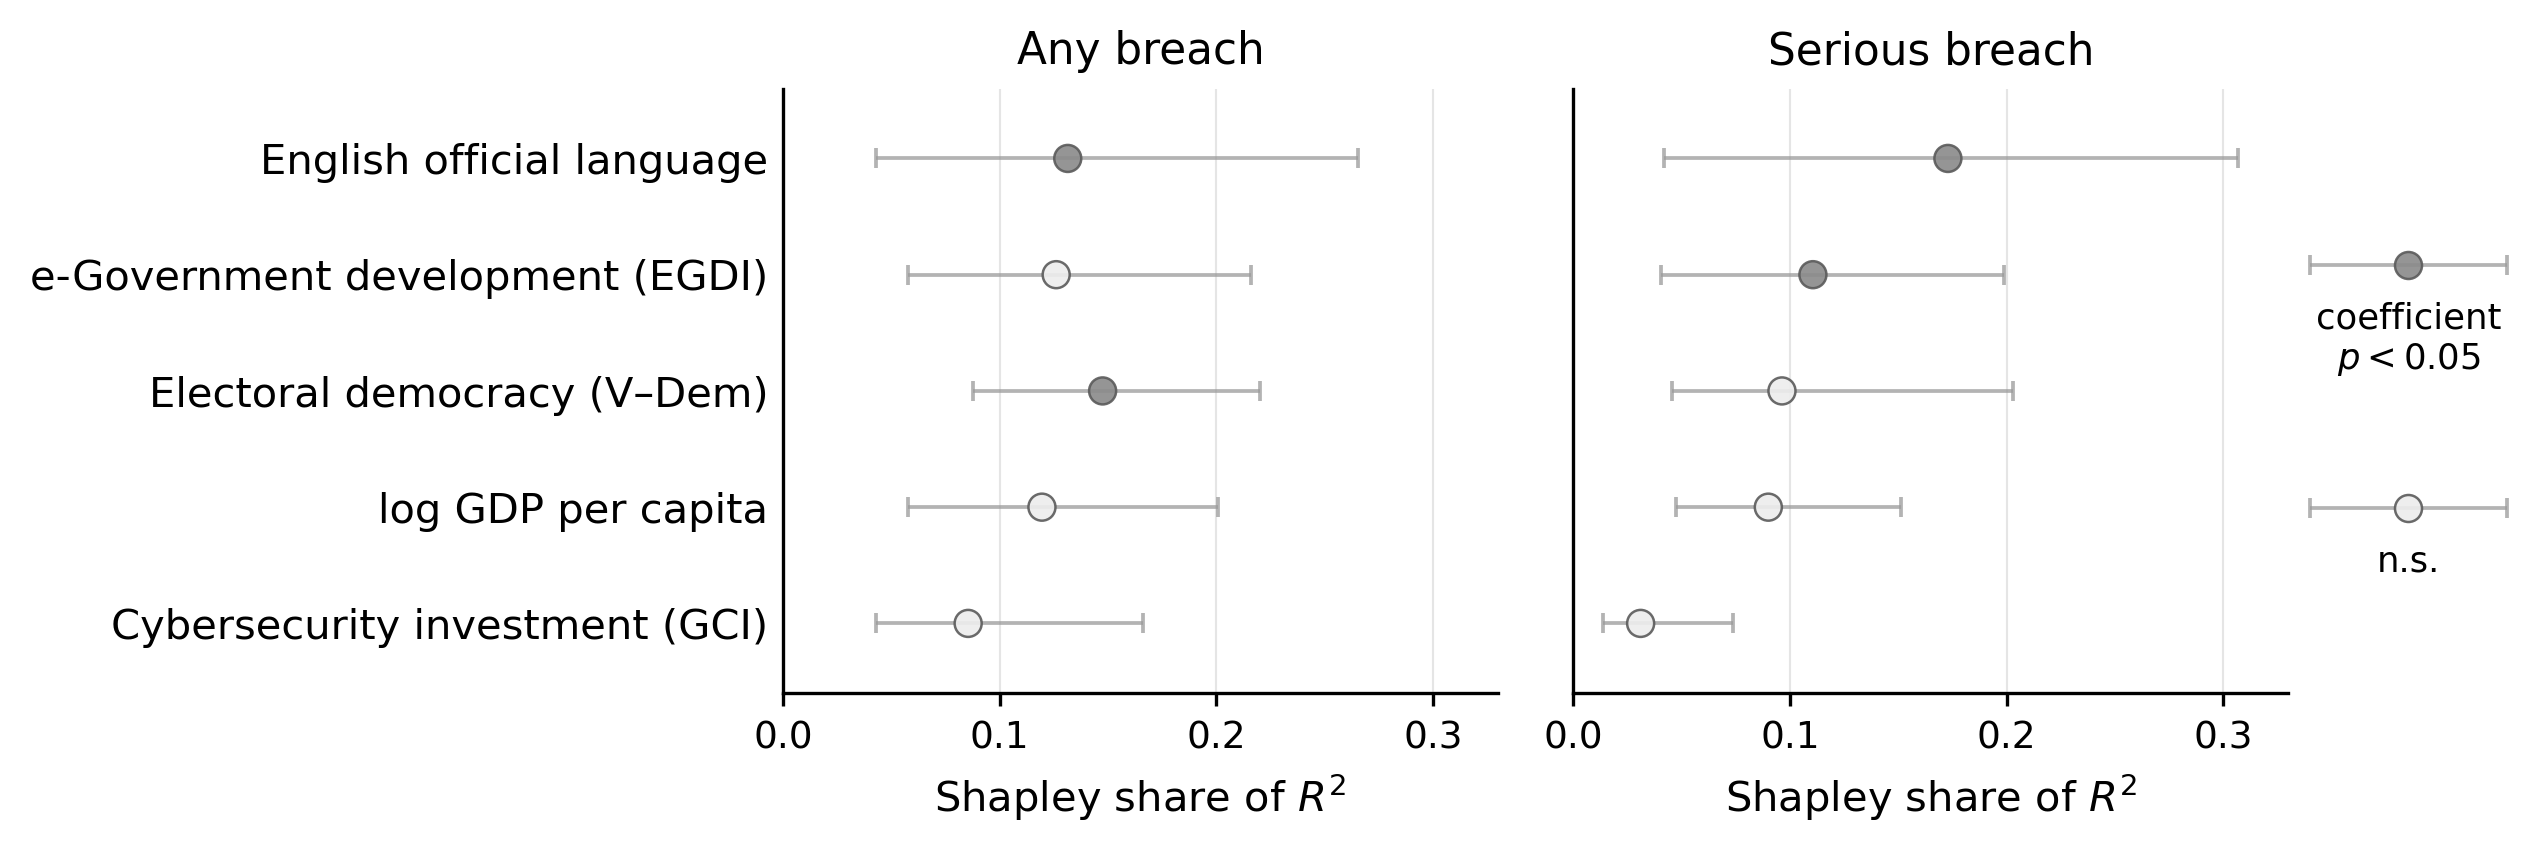

In [ ]:
# rows ordered by serious-breach share
pvals = {name: results[f"{name} M2"].pvalues for name in OUTCOMES}
labels = {
    "english": "English official language",
    "egdi": "e-Government development (EGDI)",
    "vdem": "Electoral democracy (V\u2013Dem)",
    "log_gdppc": "log GDP per capita",
    "gci": "Cybersecurity investment (GCI)",
}
order = df_boot.query("outcome == 'serious'").sort_values("share")["cov"].tolist()

fig, axes = plt.subplots(1, 2, figsize=(8.6, 3.0), sharey=True, sharex=True)
for ax, (outcome, title) in zip(axes, [("breach", "Any breach"), ("serious", "Serious breach")]):
    d = df_boot.query("outcome == @outcome").set_index("cov").loc[order].reset_index()
    fills = ["#8A8A8A" if pvals[outcome][c] < 0.05 else "#EDEDED" for c in d["cov"]]
    # whisker = 95% bootstrap CI, marker = point estimate
    ax.errorbar(d["share"], range(len(d)), xerr=[d["share"] - d["lo95"], d["hi95"] - d["share"]],
                fmt="none", ecolor="#9A9A9A", elinewidth=0.9, capsize=2.5, capthick=0.9, alpha=0.75, zorder=2)
    ax.scatter(d["share"], range(len(d)), s=42, facecolor=fills, edgecolor="#5A5A5A",
               linewidth=0.6, alpha=0.9, zorder=3)
    ax.set_title(title, fontsize=10.5, pad=6)
    ax.set_axisbelow(True)
    ax.grid(axis="x", color="#E5E5E5", lw=0.5)
    ax.spines[["top", "right"]].set_visible(False)
    ax.set_xlim(0, 0.33)
    ax.set_xticks([0, 0.1, 0.2, 0.3])
    ax.set_xlabel("Shapley share of $R^2$", fontsize=10)
    ax.tick_params(labelsize=9, direction="out", width=0.8, length=3)
    ax.tick_params(axis="y", length=0)
axes[0].set_yticks(range(len(order)))
axes[0].set_yticklabels([labels[c] for c in order], fontsize=10)
axes[0].set_ylim(-0.6, len(order) - 0.4)

fig.tight_layout(rect=(0, 0, 0.91, 1))
pos = axes[1].get_position()
lax = fig.add_axes([pos.x1 + 0.004, 0.25, 0.085, 0.5])
lax.axis("off")
lax.set_xlim(0, 1)
lax.set_ylim(0, 1)
for y_mark, y_text, fill, text in [
    (0.88, 0.80, "#8A8A8A", "coefficient\n$p<0.05$"),
    (0.34, 0.26, "#EDEDED", "n.s."),
]:
    lax.errorbar([0.5], [y_mark], xerr=[[0.45], [0.45]], fmt="none", ecolor="#9A9A9A",
                 elinewidth=0.9, capsize=2.5, capthick=0.9, alpha=0.75)
    lax.scatter([0.5], [y_mark], s=42, facecolor=fill, edgecolor="#5A5A5A", linewidth=0.6, alpha=0.9, zorder=3)
    lax.text(0.5, y_text, text, ha="center", va="top", fontsize=8.5)
save_mpl_fig("../figures/fig_shapley", dpi=300)